In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [5]:
file_path = r"C:\Users\hp\Desktop\Case_Study_DWDM\Online Retail.xlsx"

data = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", data.shape)

data.head()

Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
print("Columns:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nDataset Shape:")
print(data.shape)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print(data.duplicated().sum())

print("\nBasic Statistics:")
display(data.describe(include='all'))

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Dataset Shape:
(541909, 8)

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows:
5268

Basic Statistics:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [7]:

clean_data = data.copy()

# Convert InvoiceNo to string
clean_data['InvoiceNo'] = clean_data['InvoiceNo'].astype(str)

# 1. Remove cancelled transactions
clean_data = clean_data[
    ~clean_data['InvoiceNo'].str.startswith('C')
]

# 2. Remove transactions with missing CustomerID
clean_data = clean_data.dropna(subset=['CustomerID'])

# 3. Remove invalid quantities
clean_data = clean_data[
    clean_data['Quantity'] > 0
]

# 4. Remove invalid unit prices
clean_data = clean_data[
    clean_data['UnitPrice'] > 0
]

# 5. Remove duplicate rows
clean_data = clean_data.drop_duplicates()

# 6. Convert InvoiceDate to datetime
clean_data['InvoiceDate'] = pd.to_datetime(
    clean_data['InvoiceDate']
)

# 7. Convert CustomerID to integer
clean_data['CustomerID'] = (
    clean_data['CustomerID']
    .astype(int)
)

# 8. Create SalesAmount
clean_data['SalesAmount'] = (
    clean_data['Quantity'] *
    clean_data['UnitPrice']
)

print("Original rows:", len(data))
print("Cleaned rows:", len(clean_data))
print("Rows removed:", len(data) - len(clean_data))

print("\nMissing values after cleaning:")
print(clean_data.isnull().sum())

print("\nDuplicate rows after cleaning:",
      clean_data.duplicated().sum())

clean_data.head()

Original rows: 541909
Cleaned rows: 392692
Rows removed: 149217

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
SalesAmount    0
dtype: int64

Duplicate rows after cleaning: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [8]:
print("Unique Customers:", data['CustomerID'].nunique())
print("Unique Products:", data['StockCode'].nunique())
print("Unique Invoices:", data['InvoiceNo'].nunique())
print("Unique Countries:", data['Country'].nunique())

print("\nDate Range:")
print("Start:", data['InvoiceDate'].min())
print("End:", data['InvoiceDate'].max())

Unique Customers: 4372
Unique Products: 4070
Unique Invoices: 25900
Unique Countries: 38

Date Range:
Start: 2010-12-01 08:26:00
End: 2011-12-09 12:50:00


In [9]:
customer_data = clean_data.groupby('CustomerID').agg(
    Total_Spending=('SalesAmount', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique'),
    Total_Quantity=('Quantity', 'sum'),
    Last_Purchase=('InvoiceDate', 'max'),
    First_Purchase=('InvoiceDate', 'min'),
    Unique_Products=('StockCode', 'nunique')
).reset_index()

customer_data.head()

,CustomerID,Total_Spending,Total_Orders,Total_Quantity,Last_Purchase,First_Purchase,Unique_Products
0,12346,77183.60,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,1
1,12347,4310.00,7,2458,2011-12-07 15:52:00,2010-12-07 14:57:00,103
2,12348,1797.24,4,2341,2011-09-25 13:13:00,2010-12-16 19:09:00,22
3,12349,1757.55,1,631,2011-11-21 09:51:00,2011-11-21 09:51:00,73
4,12350,334.40,1,197,2011-02-02 16:01:00,2011-02-02 16:01:00,17


In [10]:
reference_date = clean_data['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_data['Recency'] = (
    reference_date - customer_data['Last_Purchase']
).dt.days

customer_data['Frequency'] = customer_data['Total_Orders']

customer_data['Monetary'] = customer_data['Total_Spending']

customer_data[['CustomerID', 'Recency', 'Frequency', 'Monetary']].head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [11]:
customer_data[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


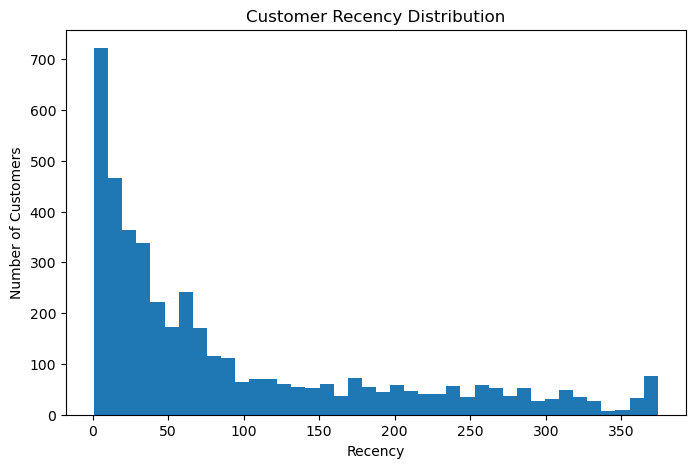

In [12]:
plt.figure(figsize=(8,5))

plt.hist(customer_data['Recency'], bins=40)

plt.xlabel('Recency')
plt.ylabel('Number of Customers')
plt.title('Customer Recency Distribution')

plt.show()

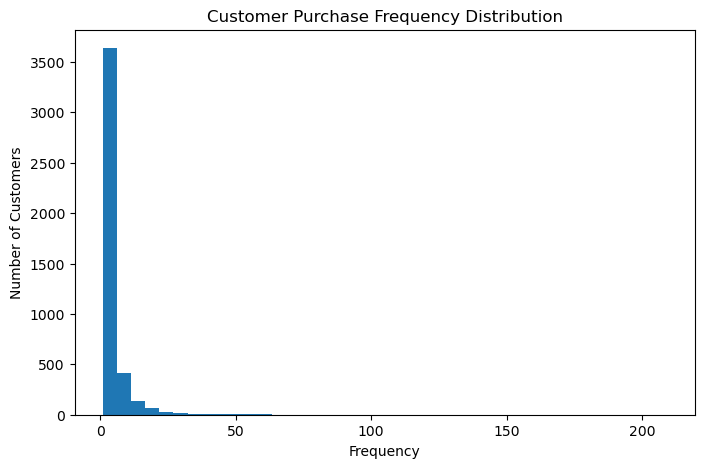

In [13]:
plt.figure(figsize=(8,5))

plt.hist(customer_data['Frequency'], bins=40)

plt.xlabel('Frequency')
plt.ylabel('Number of Customers')
plt.title('Customer Purchase Frequency Distribution')

plt.show()

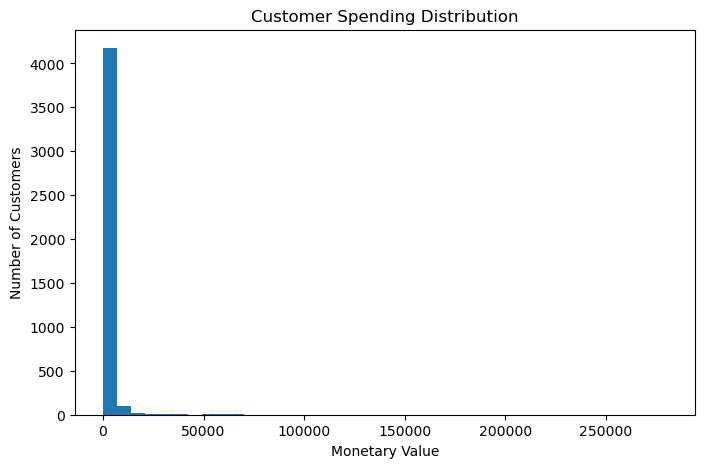

In [14]:
plt.figure(figsize=(8,5))

plt.hist(customer_data['Monetary'], bins=40)

plt.xlabel('Monetary Value')
plt.ylabel('Number of Customers')
plt.title('Customer Spending Distribution')

plt.show()

**Top 10 Customers**

In [15]:
top_customers = customer_data.sort_values(
    'Monetary',
    ascending=False
).head(10)

top_customers[
    ['CustomerID', 'Recency', 'Frequency', 'Monetary']
]

,CustomerID,Recency,Frequency,Monetary
1689,14646,2,73,280206.02
4201,18102,1,60,259657.30
3728,17450,8,46,194390.79
3008,16446,1,2,168472.50
1879,14911,1,201,143711.17
55,12415,24,21,124914.53
1333,14156,10,55,117210.08
3771,17511,3,31,91062.38
2702,16029,39,63,80850.84
0,12346,326,1,77183.60


##Feature Engineering

In [16]:
customer_data['Average_Order_Value'] = (
    customer_data['Monetary'] /
    customer_data['Frequency']
)

customer_data['Customer_Lifetime_Days'] = (
    customer_data['Last_Purchase'] -
    customer_data['First_Purchase']
).dt.days

customer_data['Purchase_Rate'] = (
    customer_data['Frequency'] /
    (customer_data['Customer_Lifetime_Days'] + 1)
)

customer_data[
    [
        'CustomerID',
        'Recency',
        'Frequency',
        'Monetary',
        'Average_Order_Value',
        'Customer_Lifetime_Days',
        'Purchase_Rate'
    ]
].head()

,CustomerID,Recency,Frequency,Monetary,Average_Order_Value,Customer_Lifetime_Days,Purchase_Rate
0,12346,326,1,77183.60,77183.600000,0,1.000000
1,12347,2,7,4310.00,615.714286,365,0.019126
2,12348,75,4,1797.24,449.310000,282,0.014134
3,12349,19,1,1757.55,1757.550000,0,1.000000
4,12350,310,1,334.40,334.400000,0,1.000000


Select ML Features

In [17]:
rfm_features = customer_data[
    ['Recency', 'Frequency', 'Monetary']
].copy()

rfm_features.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


Log Transformation

In [18]:
rfm_log = np.log1p(rfm_features)

rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


Scaling

In [19]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

print(rfm_scaled.shape)

(4338, 3)


Model 1: K-Means Clustering

In [20]:
inertia = []
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(rfm_scaled)
    
    inertia.append(model.inertia_)
    
    silhouette_scores.append(
        silhouette_score(rfm_scaled, labels)
    )

c:\Users\hp\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\hp\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\hp\Anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hp\Anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\hp\Anaconda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, arg

Elbow Method

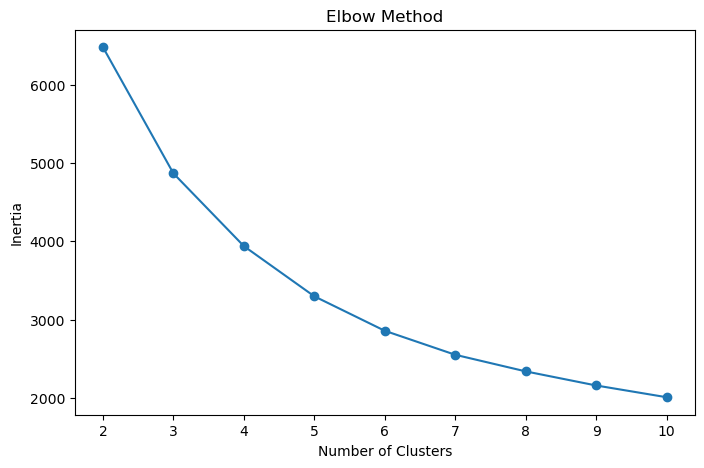

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.xticks(range(2, 11))

plt.show()

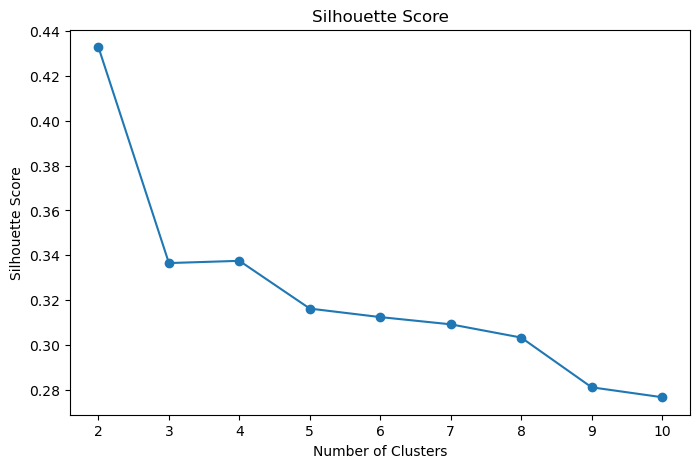

Best K: 2
Best Silhouette Score: 0.4328


In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.xticks(range(2, 11))

plt.show()

best_k = list(range(2, 11))[
    np.argmax(silhouette_scores)
]

print("Best K:", best_k)
print(
    "Best Silhouette Score:",
    round(max(silhouette_scores), 4)
)

In [23]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

customer_data['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

customer_data[
    [
        'CustomerID',
        'Recency',
        'Frequency',
        'Monetary',
        'Cluster'
    ]
].head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,1
1,12347,2,7,4310.00,1
2,12348,75,4,1797.24,1
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,0


In [24]:
final_silhouette = silhouette_score(
    rfm_scaled,
    customer_data['Cluster']
)

print(
    "Final Silhouette Score:",
    round(final_silhouette, 4)
)

Final Silhouette Score: 0.4328


In [25]:
cluster_summary = customer_data.groupby(
    'Cluster'
).agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Order_Value=('Average_Order_Value', 'mean')
).reset_index()

cluster_summary

,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Order_Value
0,0,2672,134.091317,1.671033,495.594945,320.200911
1,1,1666,25.888956,8.443577,4539.603362,573.931791


In [30]:
!pip install plotly

In [31]:
import plotly.express as px

In [32]:
fig = px.scatter_3d(
    customer_data,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster',
    title='3D Customer Segmentation using K-Means',
    hover_data=['CustomerID']
)

fig.update_layout(
    scene=dict(
        xaxis_title='Recency',
        yaxis_title='Frequency',
        zaxis_title='Monetary'
    )
)

fig.show()

In [27]:
for cluster in sorted(customer_data['Cluster'].unique()):
    group = customer_data[
        customer_data['Cluster'] == cluster
    ]
    
    print("Cluster:", cluster)
    print("Customers:", len(group))
    print("Average Recency:", round(group['Recency'].mean(), 2))
    print("Average Frequency:", round(group['Frequency'].mean(), 2))
    print("Average Monetary:", round(group['Monetary'].mean(), 2))
    print("Average Order Value:", round(group['Average_Order_Value'].mean(), 2))
    print()

Cluster: 0
Customers: 2672
Average Recency: 134.09
Average Frequency: 1.67
Average Monetary: 495.59
Average Order Value: 320.2

Cluster: 1
Customers: 1666
Average Recency: 25.89
Average Frequency: 8.44
Average Monetary: 4539.6
Average Order Value: 573.93



In [28]:
cluster_percentage = (
    customer_data['Cluster']
    .value_counts(normalize=True)
    .sort_index() * 100
)

cluster_percentage

Cluster
0    61.595205
1    38.404795
Name: proportion, dtype: float64

Model 2: Agglomerative Hierarchical Clustering

In [33]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [34]:
hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(rfm_scaled)

customer_data['Hierarchical_Cluster'] = hierarchical_labels

In [35]:
hierarchical_silhouette = silhouette_score(
    rfm_scaled,
    hierarchical_labels
)

print("Agglomerative Silhouette Score:", hierarchical_silhouette)

Agglomerative Silhouette Score: 0.4040095316978202


In [36]:
model_comparison = pd.DataFrame({
    'Model': ['K-Means', 'Agglomerative Clustering'],
    'Silhouette Score': [
        final_silhouette,
        hierarchical_silhouette
    ]
})

print(model_comparison)

                      Model  Silhouette Score
0                   K-Means          0.432827
1  Agglomerative Clustering          0.404010


In [37]:
import plotly.express as px

fig = px.scatter_3d(
    customer_data,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Hierarchical_Cluster',
    title='3D Customer Segmentation using Agglomerative Clustering',
    hover_data=['CustomerID']
)

fig.update_layout(
    scene=dict(
        xaxis_title='Recency',
        yaxis_title='Frequency',
        zaxis_title='Monetary'
    )
)

fig.show()

In [38]:
hierarchical_summary = customer_data.groupby(
    'Hierarchical_Cluster'
).agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

print(hierarchical_summary)

   Hierarchical_Cluster  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
0                     0       3233   120.502011       2.293845    874.832720
1                     1       1105    10.714932      10.059729   5483.144534


In [39]:
fig = px.bar(
    model_comparison,
    x='Model',
    y='Silhouette Score',
    title='Clustering Model Comparison',
    text='Silhouette Score'
)

fig.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside'
)

fig.show()

In [43]:
customer_data.to_csv(
    'customer_segmentation_results.csv',
    index=False
)

model_comparison.to_csv(
    'model_comparison.csv',
    index=False
)

print("Results saved successfully")


Results saved successfully


In [44]:
import joblib

joblib.dump(
    kmeans,
    'customer_segmentation_kmeans.pkl'
)

joblib.dump(
    hierarchical,
    'customer_segmentation_hierarchical.pkl'
)

joblib.dump(
    scaler,
    'customer_scaler.pkl'
)

print("Models and scaler saved successfully")

Models and scaler saved successfully
